In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anvarnarz/tashkent-real-estate-2019/uybor.xlsx


In [2]:
df = pd.read_excel("/kaggle/input/datasets/anvarnarz/tashkent-real-estate-2019/uybor.xlsx")
df.head()

,address,district,rooms,size,level,max_levels,price,lat,lng
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000,41.300156,69.210831


In [3]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7421 entries, 0 to 7420
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   address     7421 non-null   object 
 1   district    7421 non-null   object 
 2   rooms       7421 non-null   int64  
 3   size        7421 non-null   float64
 4   level       7421 non-null   int64  
 5   max_levels  7421 non-null   int64  
 6   price       7421 non-null   int64  
 7   lat         7421 non-null   float64
 8   lng         7421 non-null   float64
dtypes: float64(3), int64(4), object(2)
memory usage: 521.9+ KB


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


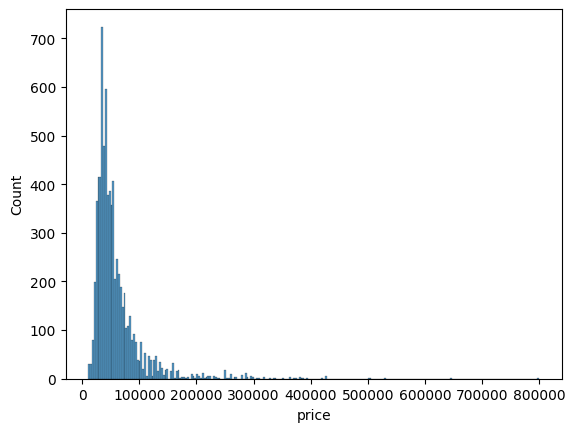

In [5]:
sns.histplot(data = df, x = 'price')
plt.show()

In [7]:
# 200000 dan qimmat uylar deyarli kam ekan shu sabab ularni tashlab yuboramiz
df = df[df.price<200000]

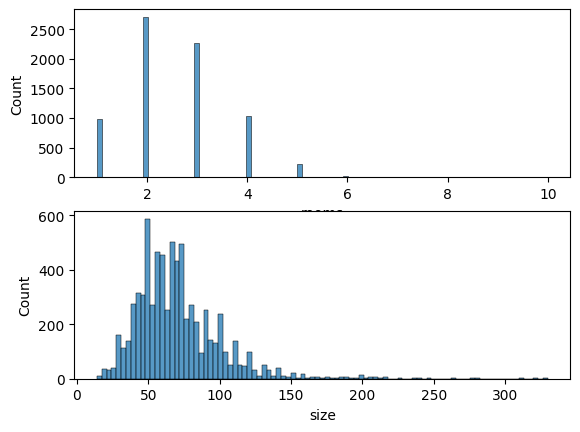

In [8]:
plt.subplot(2,1,1)
sns.histplot(data = df, x = 'rooms')
plt.subplot(2,1,2)
sns.histplot(data = df, x = 'size')
plt.show()

In [9]:
#uylar soni 5tadan kam va maydoni 250dan kam bolishi deyarli yaxshi ekan 
df = df[df.rooms<6]
df = df[df['size'] < 250]

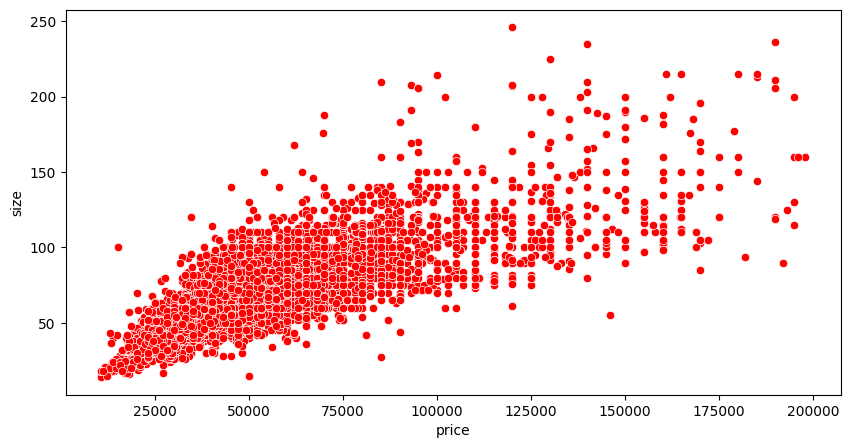

In [10]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df, x = 'price',y = 'size',
                color = 'r')
plt.show()

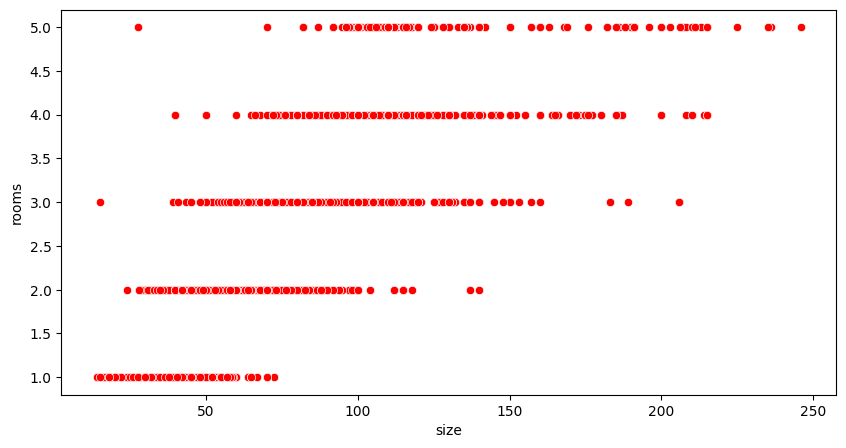

In [11]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df, x = 'size',y = 'rooms',
                color = 'r')
plt.show()

<Axes: >

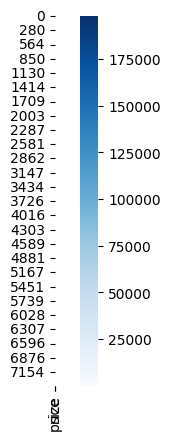

In [28]:
sns.heatmap(data = df[['price', 'size']], cmap = 'Blues', linewidth = 1, square = True)

In [29]:
df.head(
    
)

,address,district,rooms,size,level,max_levels,price,lat,lng
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000,41.300156,69.210831


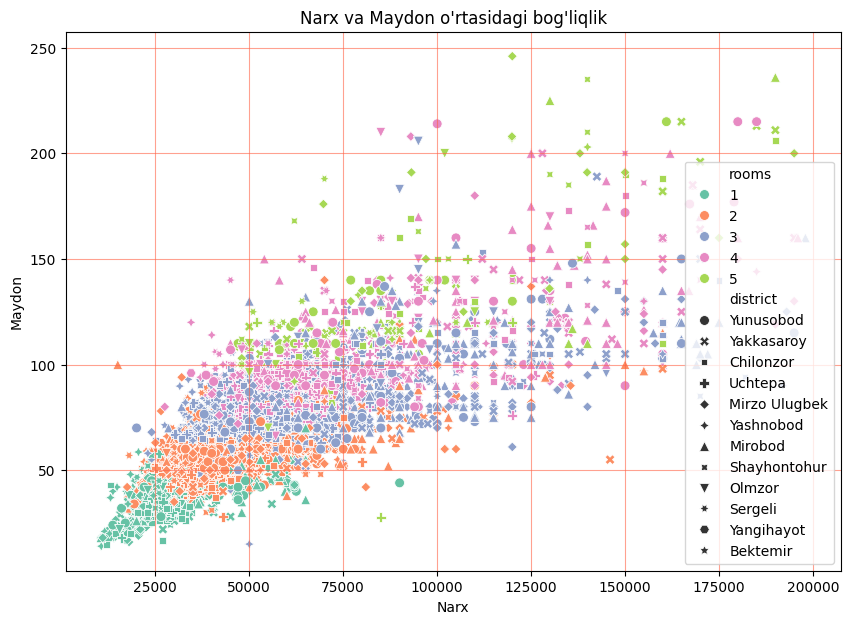

In [30]:
plt.figure(figsize = (10, 7))
sns.scatterplot(data = df, x = 'price', y = 'size', hue = 'rooms', palette = 'Set2', style = 'district' ,s = 50 )
plt.title("Narx va Maydon o'rtasidagi bog'liqlik")
plt.xlabel('Narx')l
plt.ylabel('Maydon')
plt.grid(which = 'both', color = 'tomato', alpha = 0.6)
plt.show()

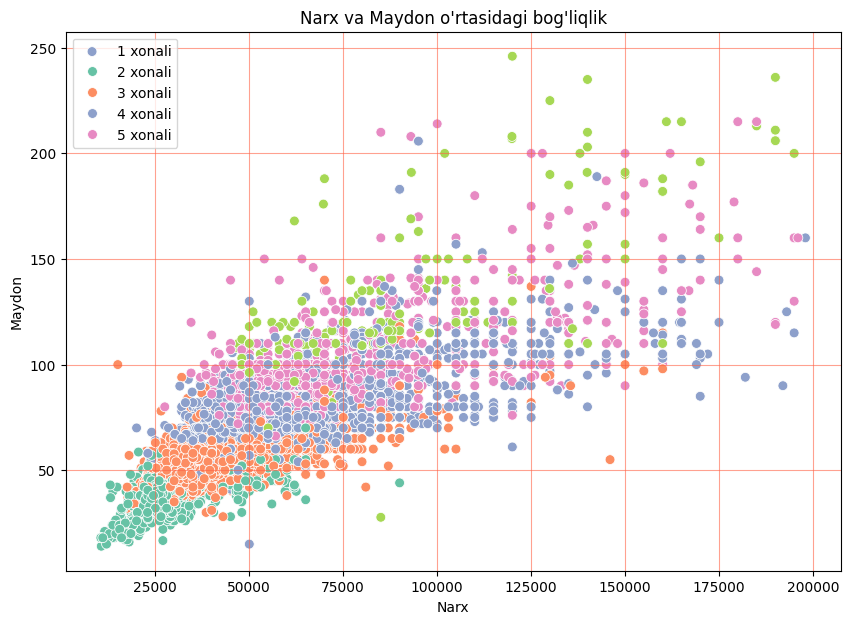

In [26]:
plt.figure(figsize = (10, 7))
sns.scatterplot(data = df, x = 'price', y = 'size', hue = 'rooms', palette = 'Set2', s = 50)
plt.legend(labels = ['1 xonali', '2 xonali', '3 xonali','4 xonali', '5 xonali'], loc = 2)
plt.title("Narx va Maydon o'rtasidagi bog'liqlik")
plt.xlabel('Narx')
plt.ylabel('Maydon')
plt.grid(which = 'both', color = 'tomato', alpha = 0.6)
plt.show()

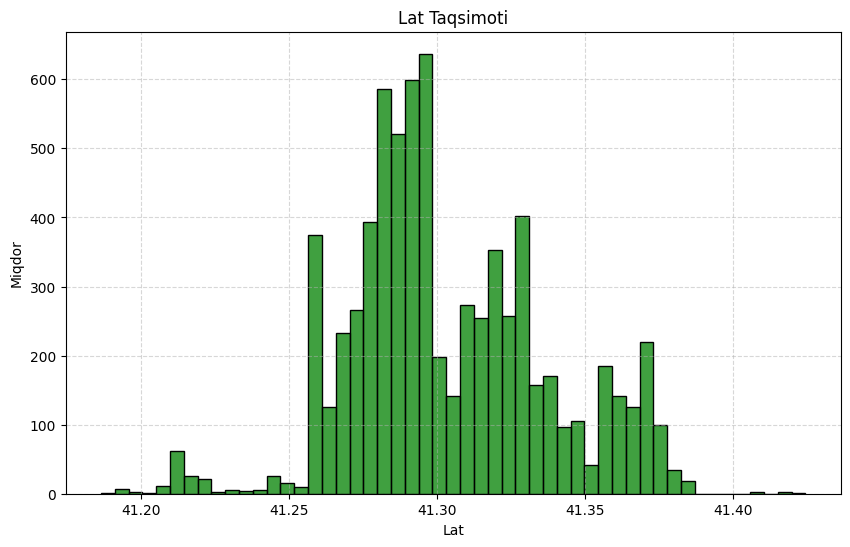

In [12]:
plt.figure(figsize = (10, 6))
sns.histplot(data = df, x = 'lat', color= 'g')
plt.title('Lat Taqsimoti')
plt.xlabel('Lat')
plt.ylabel('Miqdor')
plt.grid(which = 'both', linestyle = '--', alpha = 0.5)
plt.show()

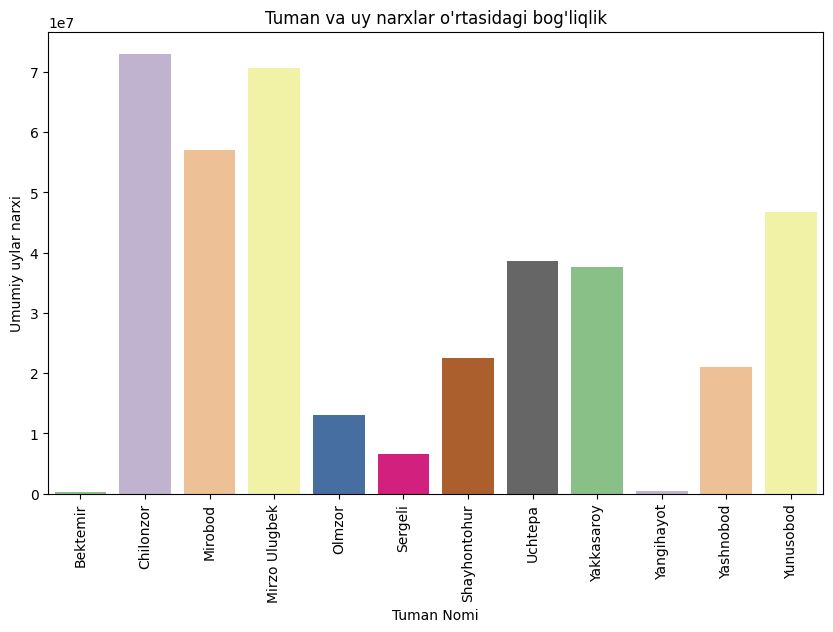

In [37]:
dist = df.groupby('district').sum(numeric_only=True)
plt.figure(figsize = (10,6))
sns.barplot(data = dist, x = dist.index, y = 'price', palette = 'Accent', legend = False, hue = dist.index)
plt.xticks(rotation = 90)
plt.xlabel('Tuman Nomi')
plt.ylabel('Umumiy uylar narxi')
plt.title("Tuman va uy narxlar o'rtasidagi bog'liqlik")
plt.show()

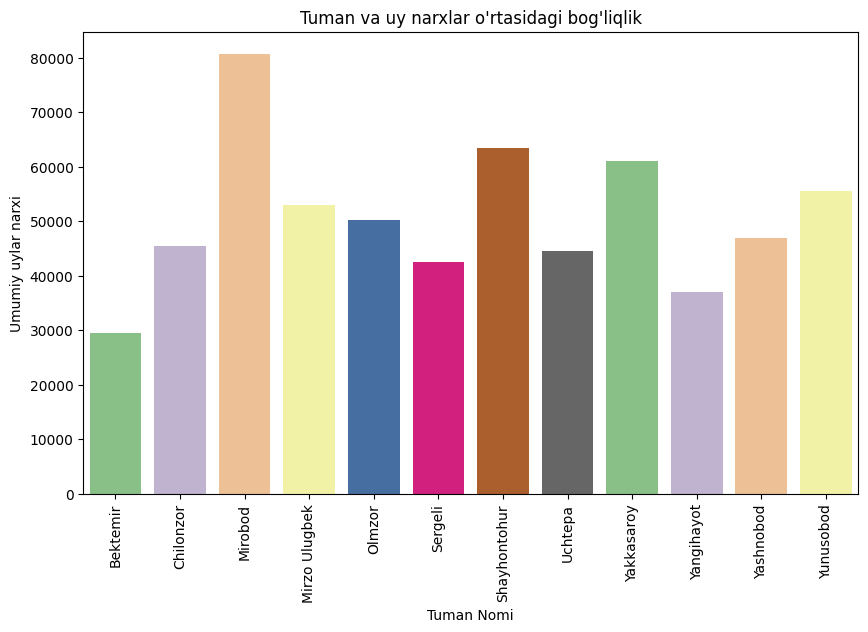

In [38]:
dist1 = df.groupby('district').mean(numeric_only=True)
plt.figure(figsize = (10,6))
sns.barplot(data = dist1, x = dist1.index, y = 'price', palette = 'Accent', legend = False, hue = dist1.index)
plt.xticks(rotation = 90)
plt.xlabel('Tuman Nomi')
plt.ylabel('Umumiy uylar narxi')
plt.title("Tuman va uy narxlar o'rtasidagi bog'liqlik")
plt.show()

<Figure size 1000x600 with 0 Axes>

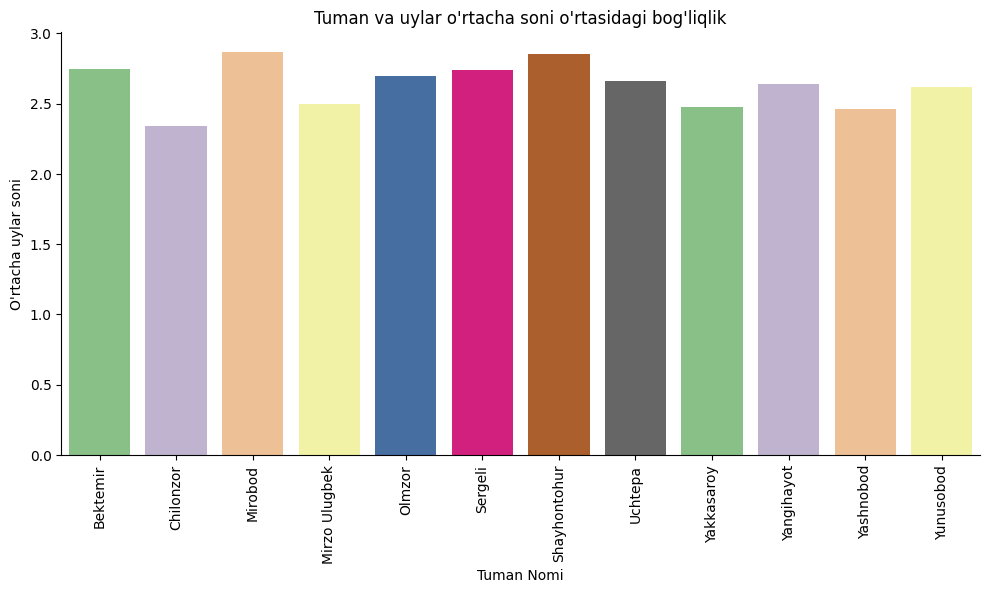

In [42]:
sns.catplot(data = dist1, x = dist1.index, y = 'rooms', kind = 'bar', hue = dist1.index, palette = 'Accent', legend = False, height = 5, aspect = 2 )
plt.xticks(rotation = 90)
plt.xlabel('Tuman Nomi')
plt.ylabel("O'rtacha uylar soni")
plt.title("Tuman va uylar o'rtacha soni o'rtasidagi bog'liqlik")
plt.show()

<Axes: ylabel='district'>

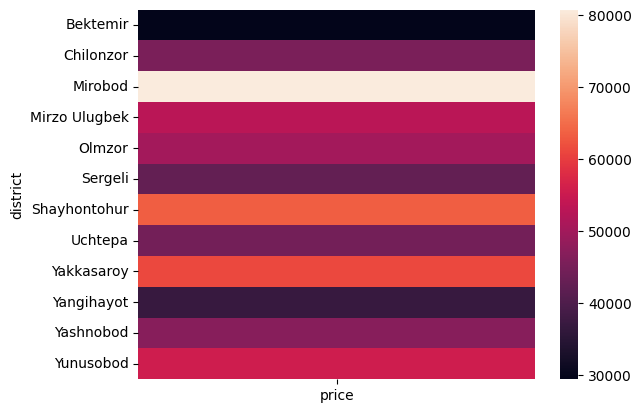

In [49]:
sns.heatmap(data = dist1[['price']])

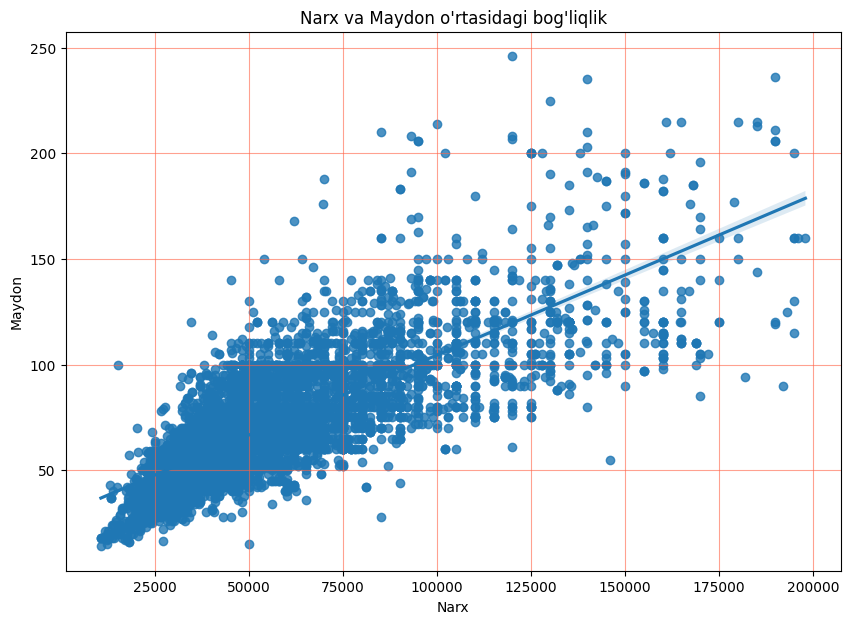

In [54]:
plt.figure(figsize = (10, 7))
sns.regplot(data = df, x = 'price', y = 'size')
plt.title("Narx va Maydon o'rtasidagi bog'liqlik")
plt.xlabel('Narx')
plt.ylabel('Maydon')
plt.grid(which = 'both', color = 'tomato', alpha = 0.6)
plt.show()

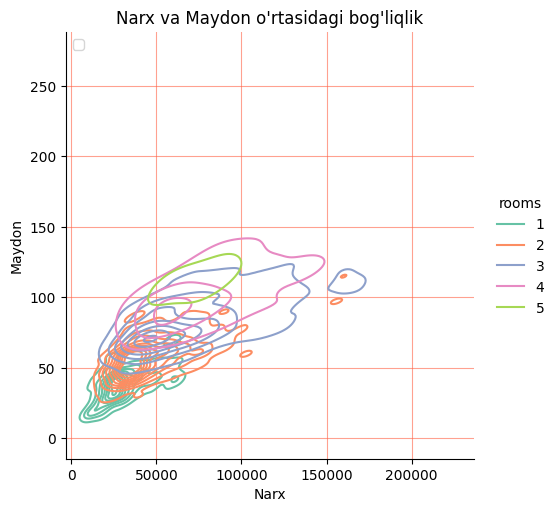

In [56]:
sns.displot(data = df, x = 'price', y = 'size', hue = 'rooms', palette = 'Set2', kind = 'kde')
plt.legend(labels = ['1 xonali', '2 xonali', '3 xonali','4 xonali', '5 xonali'], loc = 2)
plt.title("Narx va Maydon o'rtasidagi bog'liqlik")
plt.xlabel('Narx')
plt.ylabel('Maydon')
plt.grid(which = 'both', color = 'tomato', alpha = 0.6)
plt.show()

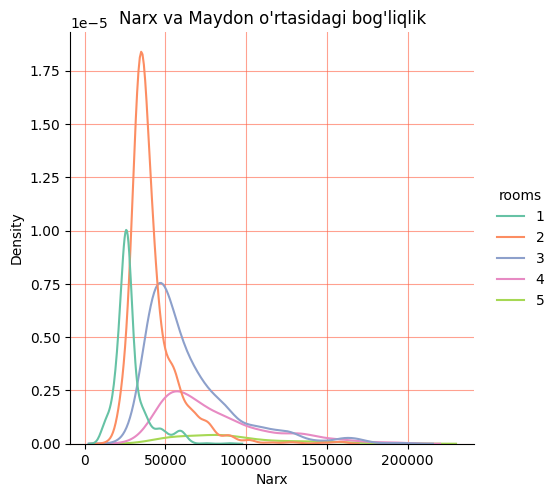

In [60]:
sns.displot(data = df, x = 'price', hue = 'rooms', palette = 'Set2', kind = 'kde')
plt.title("Narx va Maydon o'rtasidagi bog'liqlik")

plt.xlabel('Narx')

plt.grid(which = 'both', color = 'tomato', alpha = 0.6)
plt.show()

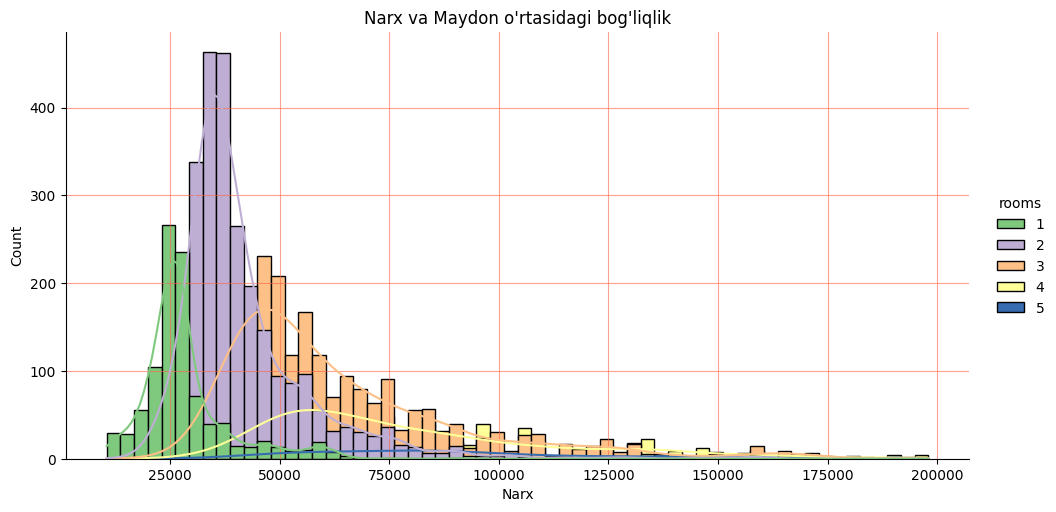

In [64]:
sns.displot(data = df, x = 'price', hue = 'rooms', palette = 'Accent', kde = True, alpha = 1, height = 5, aspect = 2)
plt.title("Narx va Maydon o'rtasidagi bog'liqlik")

plt.xlabel('Narx')

plt.grid(which = 'both', color = 'tomato', alpha = 0.6)
plt.show()

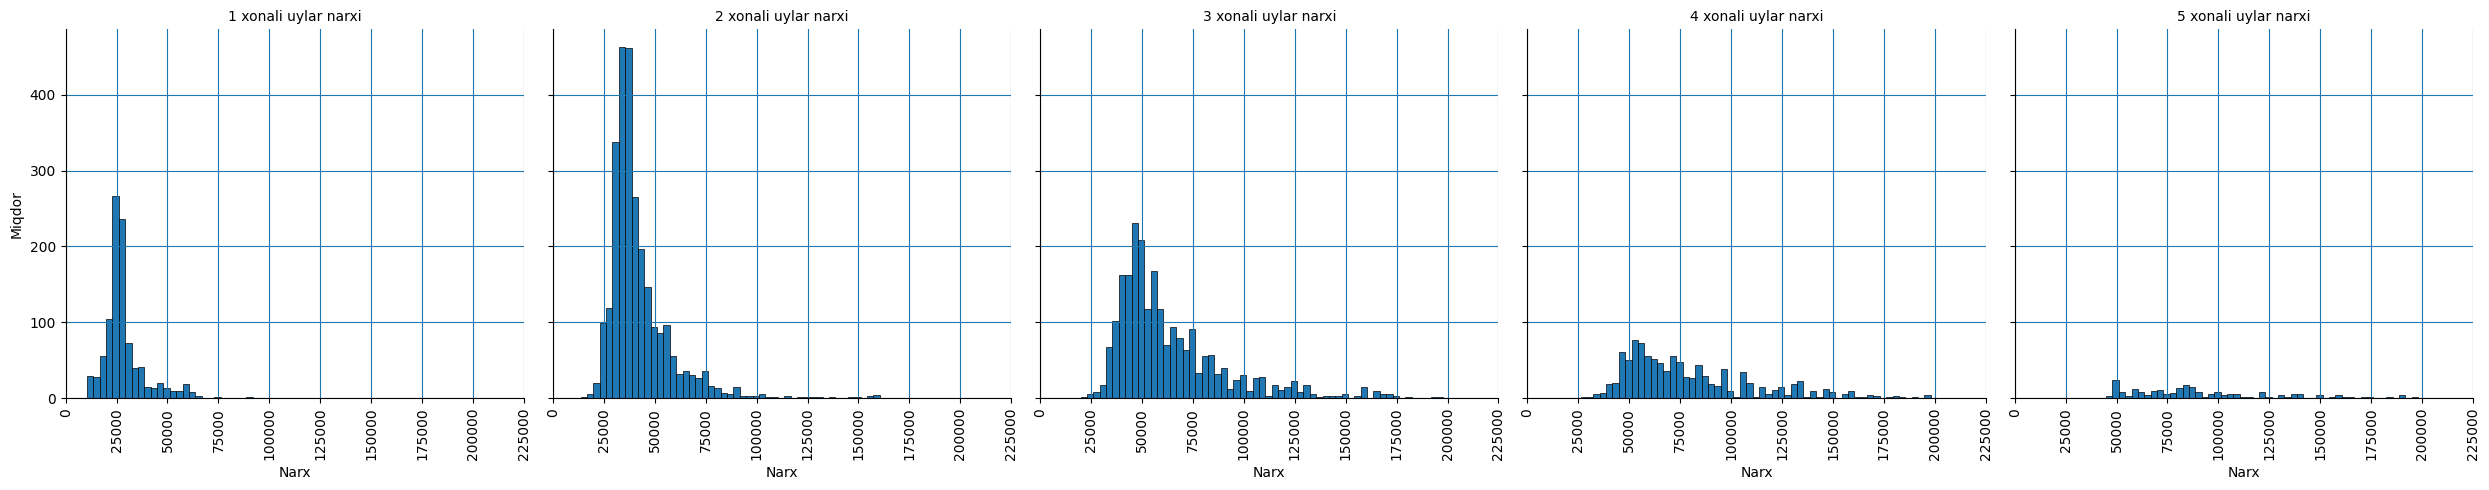

In [83]:

g = sns.displot(data = df, x = 'price', col= 'rooms', alpha = 1, fill = True)
g.set_titles("{col_name} xonali uylar narxi")
g.set_xticklabels(rotation = 90)
g.set_axis_labels('Narx', 'Miqdor')
g.map(plt.grid)
plt.show()

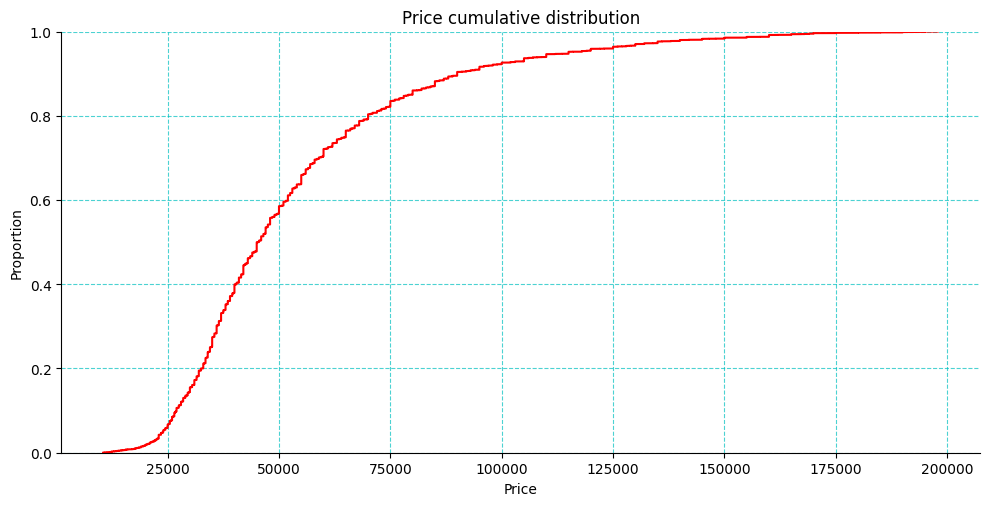

In [84]:
sns.displot(data = df, x = 'price', color = 'r', height = 5, aspect = 2, kind = 'ecdf')
plt.xlabel('Price')
plt.title('Price cumulative distribution')
plt.grid(color = 'c', alpha = 0.7, linestyle = '--' )
plt.show()

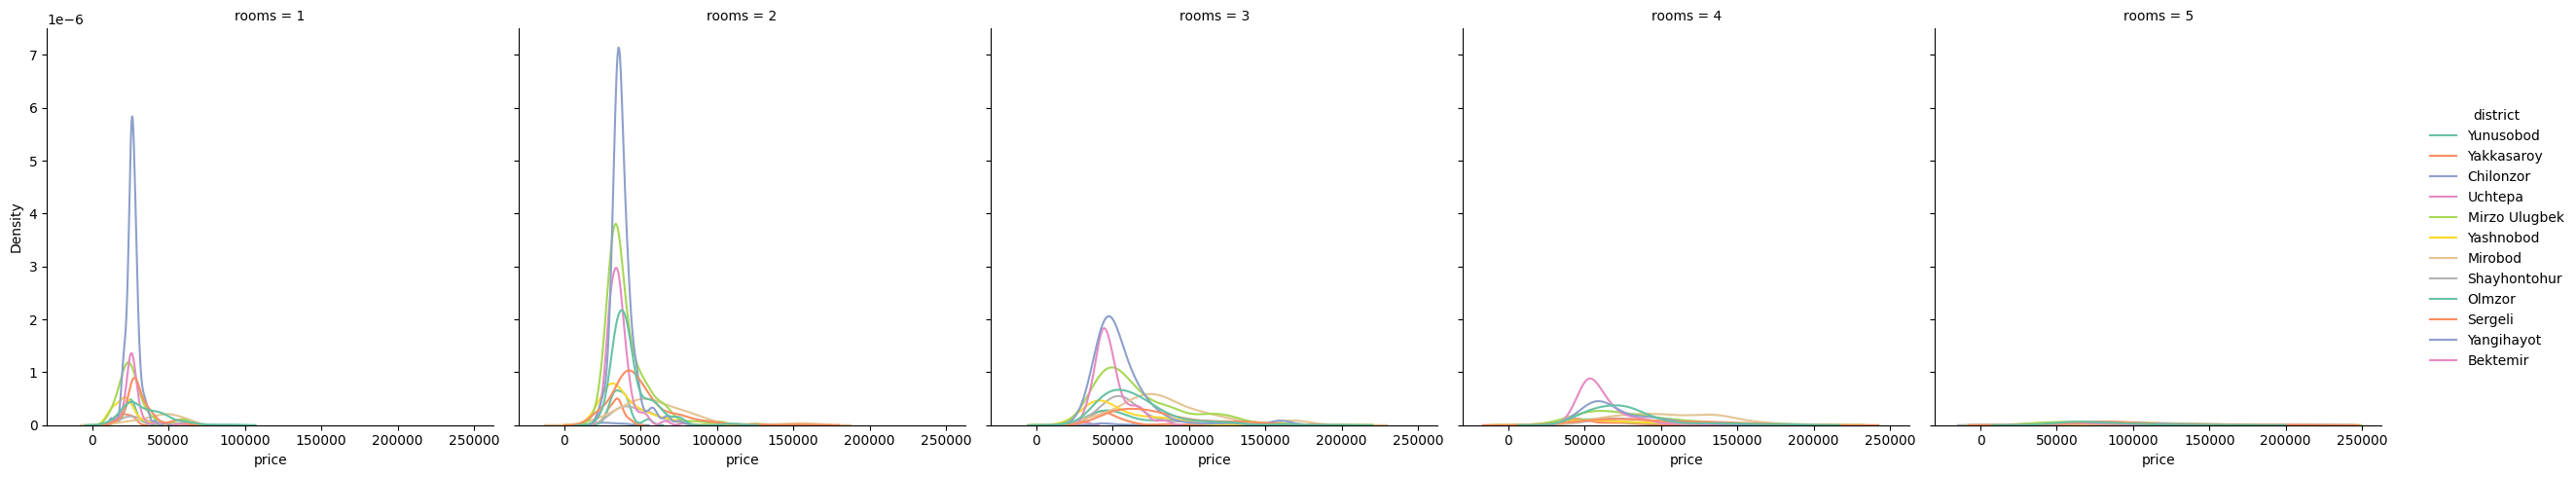

In [96]:
sns.displot(data = df, x = 'price', col = 'rooms', hue = 'district' ,palette = 'Set2', kind = 'kde', warn_singular = False)


plt.show()

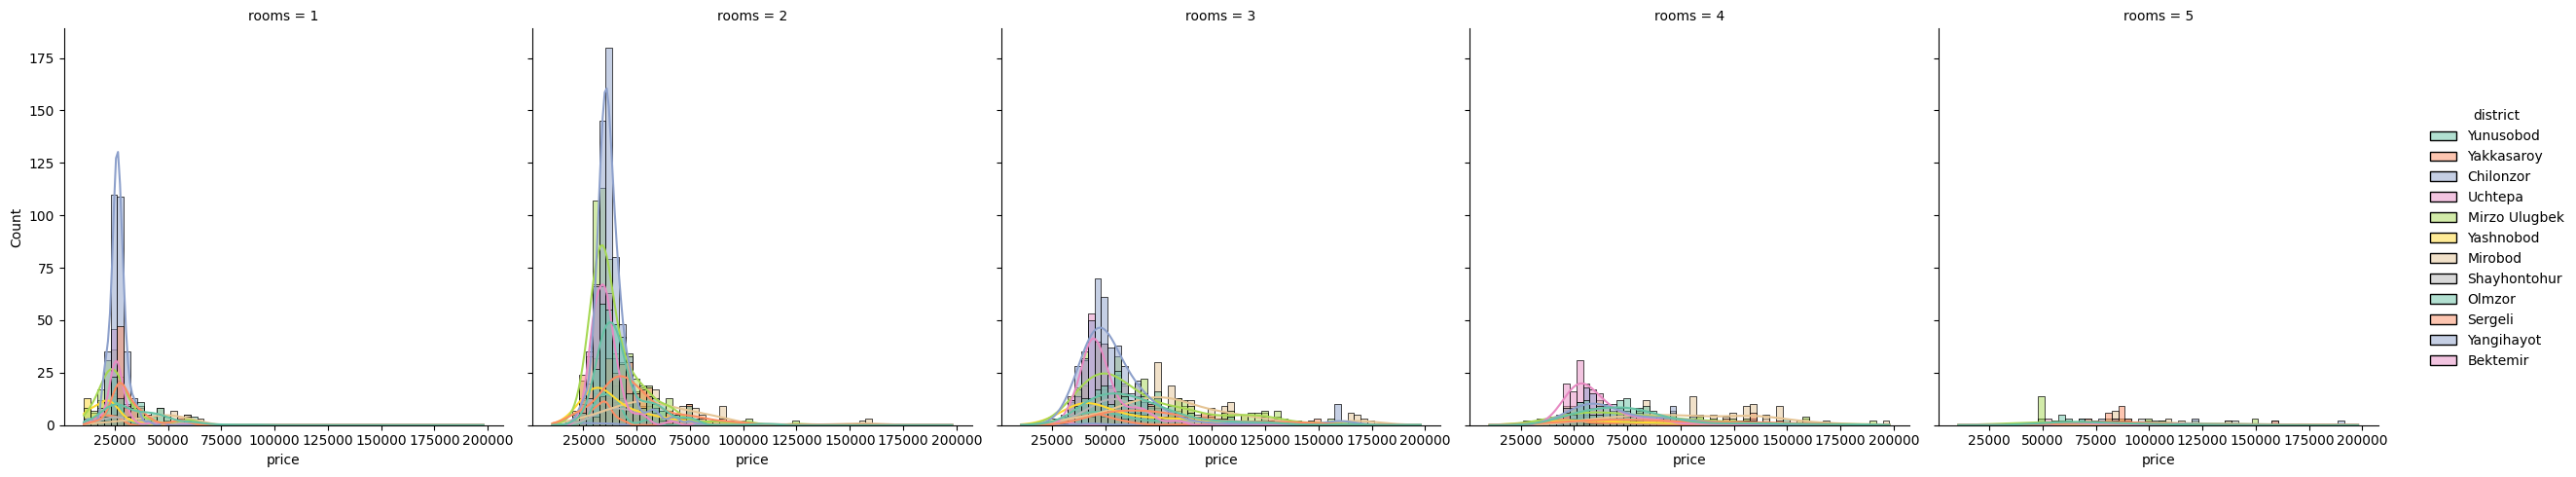

In [98]:
sns.displot(data = df, x = 'price', col = 'rooms', hue = 'district' ,palette = 'Set2', kde = True)


plt.show()

In [99]:
df.head()

,address,district,rooms,size,level,max_levels,price,lat,lng
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000,41.300156,69.210831


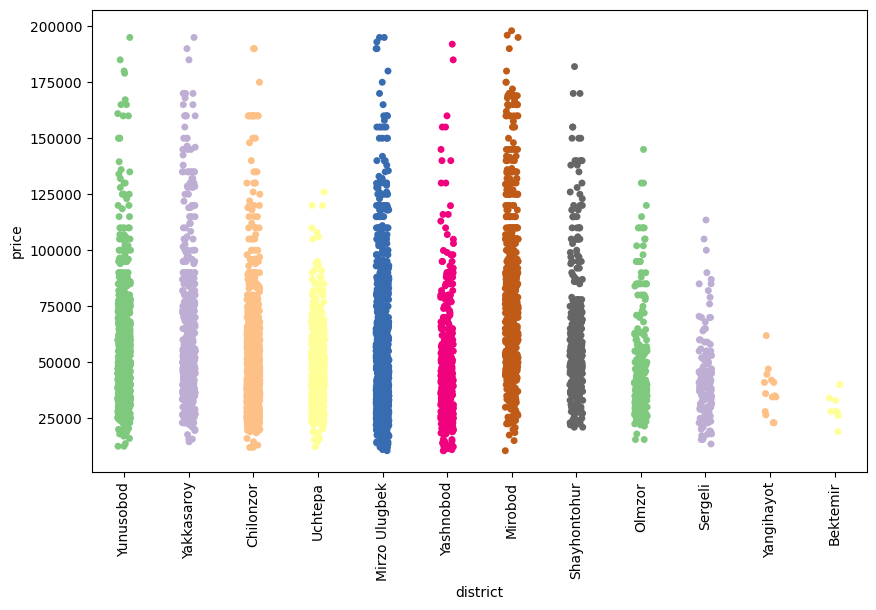

In [114]:
plt.figure(figsize = (10, 6))
sns.stripplot(data = df, x = 'district', y ='price', palette = 'Accent', hue = 'district')
plt.xticks(rotation = 90)
plt.show()

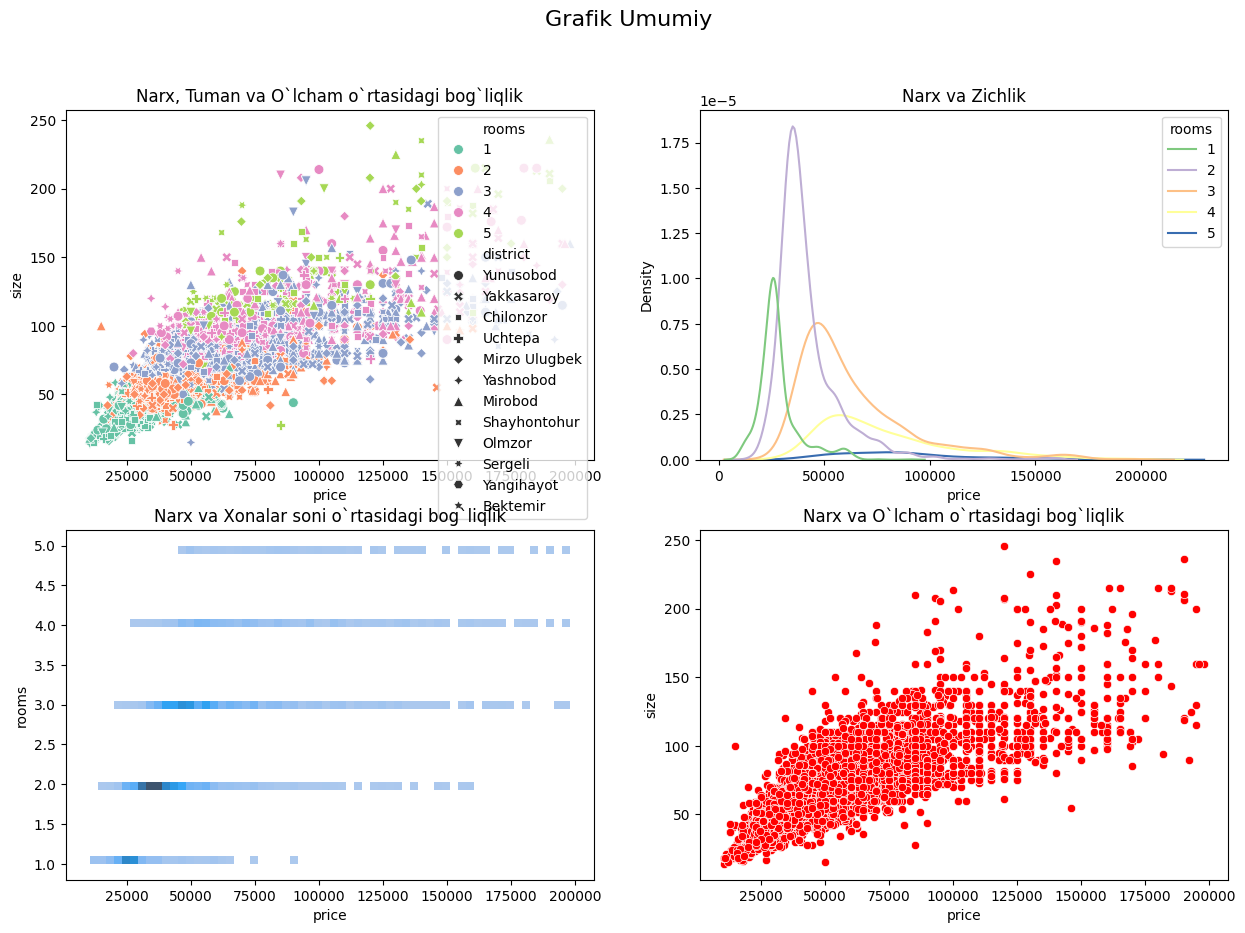

In [113]:
fig, ax = plt.subplots(2,2, figsize = (15, 10))
sns.scatterplot(ax = ax[0,0], data = df, x = 'price', y = 'size', hue = 'rooms', palette = 'Set2', style = 'district' ,s = 50 )
sns.kdeplot(ax = ax[0,1], data = df, x = 'price', hue = 'rooms', palette = 'Accent', alpha = 1)
sns.histplot(ax = ax[1,0], data = df, x = 'price', y = 'rooms')
sns.scatterplot(ax = ax[1,1], data = df, x = 'price',y = 'size',color = 'r')

fig.suptitle('Grafik Umumiy', fontsize = 16)
ax[0,0].set_title('Narx, Tuman va O`lcham o`rtasidagi bog`liqlik')
ax[0,1].set_title('Narx va Zichlik')
ax[1,0].set_title('Narx va Xonalar soni o`rtasidagi bog`liqlik')
ax[1,1].set_title('Narx va O`lcham o`rtasidagi bog`liqlik')

plt.show()

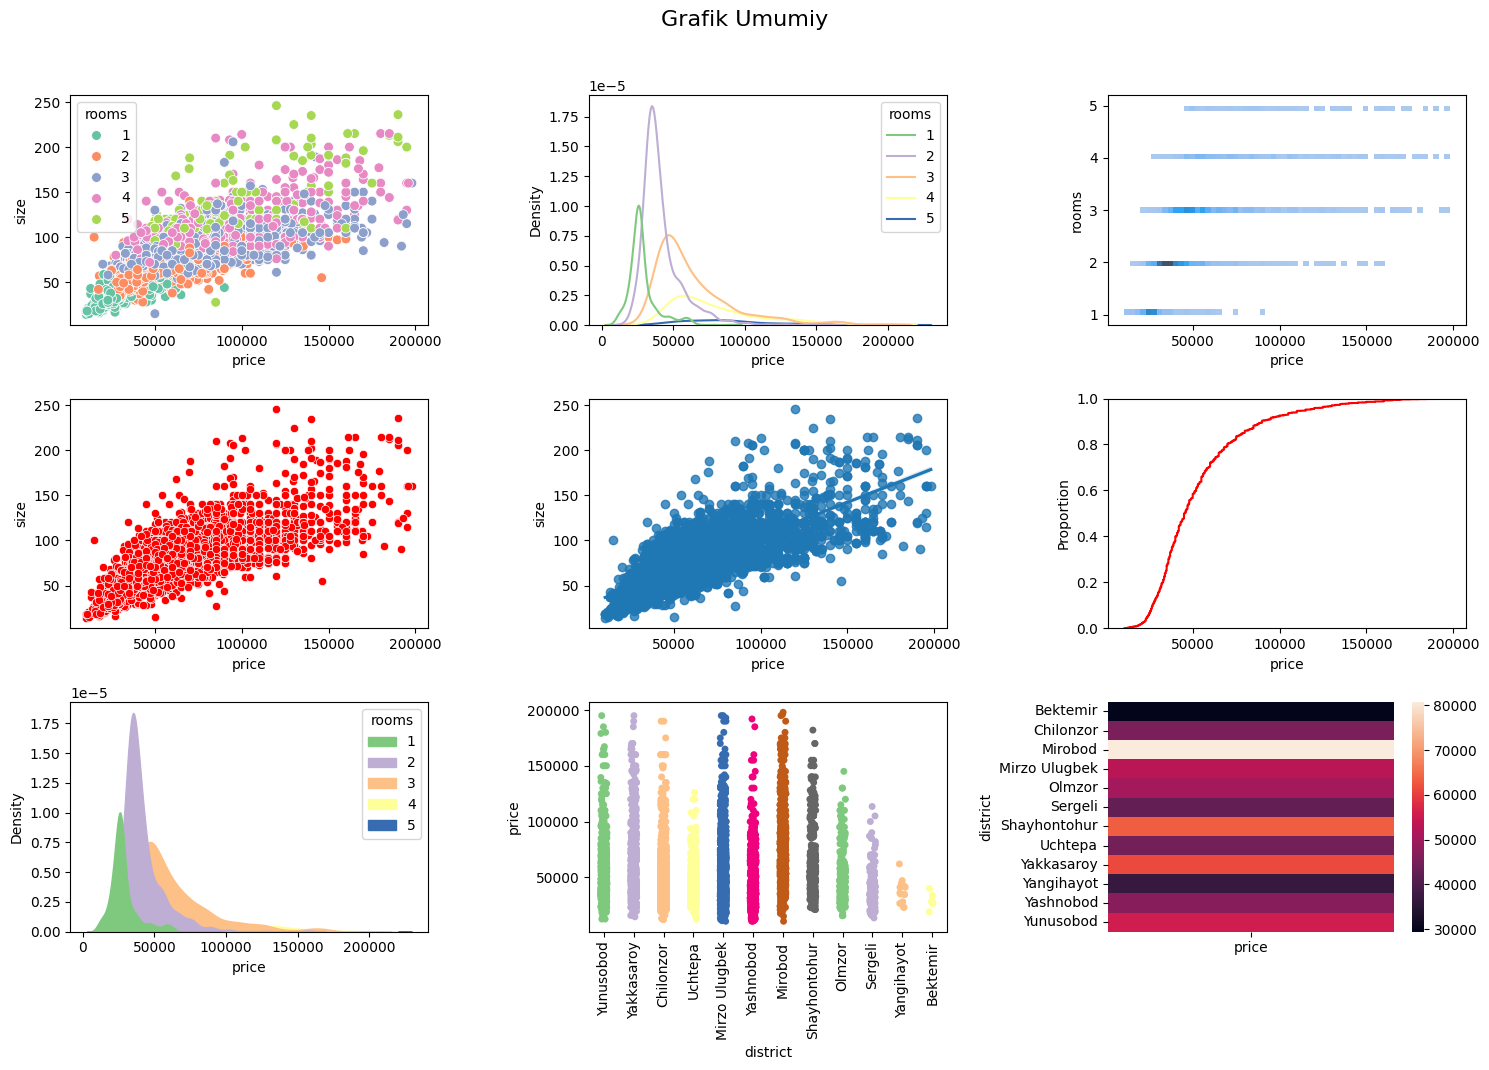

In [122]:
fig, ax = plt.subplots(3,3, figsize = (15, 10))
sns.scatterplot(ax = ax[0,0], data = df, x = 'price', y = 'size', hue = 'rooms', palette = 'Set2', s = 50 )
sns.kdeplot(ax = ax[0,1], data = df, x = 'price', hue = 'rooms', palette = 'Accent', alpha = 1)
sns.histplot(ax = ax[0,2], data = df, x = 'price', y = 'rooms')
sns.scatterplot(ax = ax[1,0], data = df, x = 'price',y = 'size',color = 'r')
sns.regplot(ax = ax[1,1], data = df, x = 'price', y = 'size')
sns.ecdfplot(ax = ax[1,2], data = df, x = 'price', color = 'r')
sns.kdeplot(ax = ax[2,0], data = df, x = 'price', hue = 'rooms', palette = 'Accent', alpha = 1, fill = True)
sns.stripplot(ax = ax[2,1], data = df, x = 'district', y ='price', palette = 'Accent', hue = 'district')
sns.heatmap(ax = ax[2,2], data = dist1[['price']])
fig.suptitle('Grafik Umumiy', fontsize = 16)
plt.tight_layout(rect = [0,0,1,0.96])
ax[2,1].tick_params(axis = 'x', rotation = 90)
plt.show(
)